# Salary Survey Data Cleaning

Dataset: `salary_survey_raw.csv`

Mục tiêu:
- Làm sạch dữ liệu
- Xử lý missing values
- Xử lý duplicates
- Chuẩn hóa dữ liệu
- Encoding
- Feature engineering
- Tạo pipeline làm sạch dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler
)

warnings.filterwarnings('ignore')

RAW_PATH = "salary_survey_raw.csv"

df_raw = pd.read_csv(RAW_PATH)

print(df_raw.shape)

df_raw.head()

(2800, 17)


,timestamp,how_old_are_you,industry,job_title,additional_context_on_job_title,annual_salary,additional_monetary_comp,currency,income_context,country,us_state,city,years_of_experience_in_field,years_of_experience_overall,highest_level_of_education,gender,race
0,04/12/2021 16:11:47,45-54,Legal,Legal Counsel,NaN,"56,894",NaN,USD,NaN,NaN,NaN,Boston,21 - 30 years,21 - 30 years,College degree,Man,Black or African American
1,04/25/2021 09:28:06,25-34,Finance,Investment Analyst,NaN,"144,543","$9,839",USD,NaN,United States,Washington,NaN,8 - 10 years,8 - 10 years,College degree,Man,Multiracial
2,04/15/2021,25-34,Nonprofit,Grant Writer,NaN,"52,304.00",NaN,AUD,NaN,United States,Washington,NaN,21 - 30 years,21 - 30 years,PhD,Woman,NaN
3,04/21/2021 03:36:47,55-64,Real Estate,Real Estate Manager,NaN,"51,765",18454,AUD,NaN,United States,NaN,Los Angeles,2 - 4 years,2 - 4 years,Master's degree,Male,NaN
4,2021-04-26 03:04,35-44,Nursing,Charge Nurse,Senior level,"133,218","8,424",USD,NaN,UK,NaN,NaN,11 - 20 years,11 - 20 years,College degree,Woman,NaN


## Rename Columns

Dataset gốc có tên cột rất dài.

Ta đổi sang tên ngắn để:
- dễ code
- dễ đọc
- tránh lỗi

In [3]:
rename_map = {
    'Timestamp': 'timestamp',

    'How old are you?': 'how_old_are_you',

    'What industry do you work in?':
        'industry',

    'Job title':
        'job_title',

    'If your job title needs additional context, please clarify here:':
        'additional_context_on_job_title',

    'What is your annual salary?':
        'annual_salary',

    'How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)?':
        'additional_monetary_comp',

    'Please indicate the currency':
        'currency',

    'If "Other," please indicate the currency here: ':
        'other_currency',

    'If your income needs additional context, please provide it here:':
        'income_context',

    'What country do you work in?':
        'country',

    "If you're in the U.S., what state do you work in?":
        'us_state',

    'What city do you work in?':
        'city',

    'How many years of professional work experience do you have overall?':
        'years_of_experience_overall',

    'How many years of professional work experience do you have in your field?':
        'years_of_experience_in_field',

    'What is your highest level of education completed?':
        'highest_level_of_education',

    'What is your gender?':
        'gender',

    'What is your race? (Choose all that apply.)':
        'race'
}

df_raw = df_raw.rename(columns=rename_map)

print(df_raw.columns.tolist())

['timestamp', 'how_old_are_you', 'industry', 'job_title', 'additional_context_on_job_title', 'annual_salary', 'additional_monetary_comp', 'currency', 'income_context', 'country', 'us_state', 'city', 'years_of_experience_in_field', 'years_of_experience_overall', 'highest_level_of_education', 'gender', 'race']


## Missing Values

Kiểm tra dữ liệu bị thiếu.

Một số cột:
- missing là hợp lệ
- một số cần fill
- một số cần giữ nguyên

In [4]:
missing = df_raw.isnull().sum()

missing_pct = (
    missing / len(df_raw) * 100
).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

missing_df = missing_df[
    missing_df['missing_count'] > 0
]

missing_df.sort_values(
    'missing_pct',
    ascending=False
)

,missing_count,missing_pct
income_context,2269,81.04
us_state,1813,64.75
city,1562,55.79
additional_monetary_comp,1538,54.93
additional_context_on_job_title,969,34.61
race,766,27.36
annual_salary,391,13.96
country,115,4.11
gender,69,2.46


### Giải thích Missing Values

- `additional_monetary_comp`
    - null nghĩa là không có bonus
    - fill 0

- `annual_salary`
    - MNAR
    - giữ null

- `race`
    - MNAR
    - giữ null

- `city`
    - fill Unknown

- `country`
    - fill Unknown

In [5]:
df = df_raw.copy()

df['income_context'] = (
    df['income_context']
    .fillna('none')
)

df['additional_context_on_job_title'] = (
    df['additional_context_on_job_title']
    .fillna('none')
)

df['country'] = (
    df['country']
    .fillna('Unknown')
)

df['city'] = (
    df['city']
    .fillna('Unknown')
)

df['us_state'] = (
    df['us_state']
    .fillna('N/A')
)

df['gender'] = (
    df['gender']
    .fillna('Prefer not to say')
)

df['salary_was_missing'] = (
    df['annual_salary']
    .isnull()
    .astype(int)
)

df['additional_monetary_comp'] = (
    pd.to_numeric(
        df['additional_monetary_comp']
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False),
        errors='coerce'
    )
    .fillna(0)
)

df.isnull().sum()

timestamp                            0
how_old_are_you                      0
industry                             0
job_title                            0
additional_context_on_job_title      0
annual_salary                      391
additional_monetary_comp             0
currency                             0
income_context                       0
country                              0
us_state                             0
city                                 0
years_of_experience_in_field         0
years_of_experience_overall          0
highest_level_of_education           0
gender                               0
race                               766
salary_was_missing                   0
dtype: int64

## Duplicate Handling

Duplicate rows có thể do:
- submit form nhiều lần
- refresh trình duyệt
- lỗi nhập liệu

Ta giữ dòng đầu tiên.

In [6]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

df = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
)

print(df.shape)

Duplicate rows: 38
(2762, 18)


## Data Type Conversion

Một số cột đang có kiểu dữ liệu sai:
- annual_salary → object
- timestamp → object

Cần chuyển sang:
- float
- datetime

In [7]:
print(df.dtypes)

timestamp                              str
how_old_are_you                        str
industry                               str
job_title                              str
additional_context_on_job_title        str
annual_salary                          str
additional_monetary_comp           float64
currency                               str
income_context                         str
country                                str
us_state                               str
city                                   str
years_of_experience_in_field           str
years_of_experience_overall            str
highest_level_of_education             str
gender                                 str
race                                   str
salary_was_missing                   int64
dtype: object


In [8]:
df['annual_salary'] = (
    df['annual_salary']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.strip()
)

df['annual_salary'] = pd.to_numeric(
    df['annual_salary'],
    errors='coerce'
)

df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    errors='coerce'
)

df['currency'] = (
    df['currency']
    .astype(str)
    .str.upper()
    .astype('category')
)

df['industry'] = (
    df['industry']
    .astype('category')
)

print(df.dtypes)

timestamp                          datetime64[us]
how_old_are_you                               str
industry                                 category
job_title                                     str
additional_context_on_job_title               str
annual_salary                             float64
additional_monetary_comp                  float64
currency                                 category
income_context                                str
country                                       str
us_state                                      str
city                                          str
years_of_experience_in_field                  str
years_of_experience_overall                   str
highest_level_of_education                    str
gender                                        str
race                                          str
salary_was_missing                          int64
dtype: object


## Outlier Detection

Dữ liệu lương thường lệch phải.

Ta dùng:
- IQR
- Boxplot

để phát hiện outlier.

In [9]:
Q1 = df['annual_salary'].quantile(0.25)

Q3 = df['annual_salary'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df['annual_salary'] < lower)
    |
    (df['annual_salary'] > upper)
]

print("Outliers:", len(outliers))

outliers[
    ['job_title', 'annual_salary']
].head()

Outliers: 111


,job_title,annual_salary
24,ML Engineer,198183.0
58,Physician,190911.0
89,Senior Consultant,197041.0
102,Software Developer,194144.0
109,Treasurer,233911.0


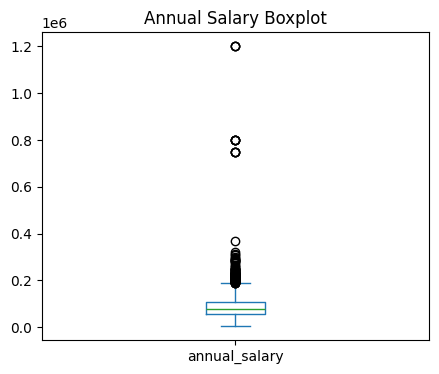

In [10]:
df['annual_salary'].plot.box(
    figsize=(5,4)
)

plt.title("Annual Salary Boxplot")

plt.show()

## Winsorization

Không xóa outlier vì:
- có thể là CEO
- executive salary hợp lệ

Ta clip:
- 1 percentile
- 99 percentile

In [11]:
p01 = df['annual_salary'].quantile(0.01)

p99 = df['annual_salary'].quantile(0.99)

df['annual_salary'] = (
    df['annual_salary']
    .clip(lower=p01, upper=p99)
)

df['annual_salary'].describe()

count      2370.000000
mean      87995.122599
std       48347.603295
min       15840.000000
25%       55320.750000
50%       78552.000000
75%      109079.500000
max      281230.440000
Name: annual_salary, dtype: float64

## String Normalization

Chuẩn hóa:
- gender
- country

để tránh:
- Female vs female
- US vs USA

In [13]:
df['gender'] = (
    df['gender']
    .astype(str)
    .str.lower()
    .str.strip()
)

gender_map = {
    'female': 'Woman',
    'woman': 'Woman',
    'male': 'Man',
    'man': 'Man'
}

df['gender'] = (
    df['gender']
    .replace(gender_map)
)

df['gender'].value_counts()

gender
Woman                      1325
Man                        1103
non-binary                  149
non-binary/third gender     117
prefer not to say            68
Name: count, dtype: int64

In [14]:
country_map = {
    'US': 'United States',
    'USA': 'United States',
    'U.S.': 'United States',
    'UK': 'United Kingdom'
}

df['country'] = (
    df['country']
    .replace(country_map)
)

df['country'].value_counts().head()

country
United States     1177
United Kingdom     261
Canada             254
Australia          179
Germany            151
Name: count, dtype: int64

## Scaling

StandardScaler:
- mean = 0
- std = 1

dùng cho machine learning.

In [15]:
scaler = StandardScaler()

df_scale = df[
    ['annual_salary']
].dropna().copy()

df_scale['salary_scaled'] = (
    scaler.fit_transform(
        df_scale[['annual_salary']]
    )
)

df_scale.head()

,annual_salary,salary_scaled
0,56894.0,-0.643417
1,144543.0,1.169858
2,52304.0,-0.738375
3,51765.0,-0.749526
4,133218.0,0.935567


## Encoding

Ordinal Encoding:
- education

One Hot Encoding:
- currency

In [16]:
edu_map = {
    'High School': 1,
    'Some college': 2,
    'College degree': 3,
    'Professional degree (MD, JD, etc.)': 4,
    "Master's degree": 5,
    'PhD': 6
}

df['education_level'] = (
    df['highest_level_of_education']
    .map(edu_map)
)

df[
    [
        'highest_level_of_education',
        'education_level'
    ]
].head()

,highest_level_of_education,education_level
0,College degree,3
1,College degree,3
2,PhD,6
3,Master's degree,5
4,College degree,3


In [17]:
currency_dummies = pd.get_dummies(
    df['currency'],
    prefix='currency',
    drop_first=True
)

df = pd.concat(
    [df, currency_dummies],
    axis=1
)

currency_dummies.head()

,currency_CAD,currency_EUR,currency_GBP,currency_INR,currency_USD,currency_USD
0,False,False,False,False,True,False
1,False,False,False,False,True,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,True,False


## Feature Engineering

Tạo:
- total_comp
- survey_month

để phục vụ phân tích.

In [18]:
df['total_comp'] = (
    df['annual_salary'].fillna(0)
    +
    df['additional_monetary_comp']
)

df['survey_month'] = (
    df['timestamp']
    .dt.month
)

df[
    ['total_comp', 'survey_month']
].head()

,total_comp,survey_month
0,56894.0,4.0
1,154382.0,4.0
2,52304.0,NaN
3,70219.0,4.0
4,141642.0,NaN


## Cleaning Pipeline

Đóng gói toàn bộ bước xử lý vào function.

In [19]:
def clean_data(df_input):

    df = df_input.copy()

    df = (
        df
        .drop_duplicates()
        .reset_index(drop=True)
    )

    df['annual_salary'] = (
        df['annual_salary']
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
    )

    df['annual_salary'] = pd.to_numeric(
        df['annual_salary'],
        errors='coerce'
    )

    df['timestamp'] = pd.to_datetime(
        df['timestamp'],
        errors='coerce'
    )

    return df


df_clean = clean_data(df)

df_clean.head()

,timestamp,how_old_are_you,industry,job_title,additional_context_on_job_title,annual_salary,additional_monetary_comp,currency,income_context,country,...,salary_was_missing,education_level,currency_CAD,currency_EUR,currency_GBP,currency_INR,currency_USD,currency_USD,total_comp,survey_month
0,2021-04-12 16:11:47,45-54,Legal,Legal Counsel,none,56894.0,0.0,USD,none,Unknown,...,0,3,False,False,False,False,True,False,56894.0,4.0
1,2021-04-25 09:28:06,25-34,Finance,Investment Analyst,none,144543.0,9839.0,USD,none,United States,...,0,3,False,False,False,False,True,False,154382.0,4.0
2,NaT,25-34,Nonprofit,Grant Writer,none,52304.0,0.0,AUD,none,United States,...,0,6,False,False,False,False,False,False,52304.0,NaN
3,2021-04-21 03:36:47,55-64,Real Estate,Real Estate Manager,none,51765.0,18454.0,AUD,none,United States,...,0,5,False,False,False,False,False,False,70219.0,4.0
4,NaT,35-44,Nursing,Charge Nurse,Senior level,133218.0,8424.0,USD,none,United Kingdom,...,0,3,False,False,False,False,True,False,141642.0,NaN


## Unit Tests

Kiểm tra:
- duplicate
- missing
- column tồn tại

In [25]:
# tạo dataframe sạch để test
df_test = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
)

# duplicate test
assert df_test.duplicated().sum() == 0

# null test
assert (
    df_test['additional_monetary_comp']
    .isnull()
    .sum()
    == 0
)

# column existence
assert 'annual_salary' in df_test.columns
assert 'total_comp' in df_test.columns

print("All tests passed.")

All tests passed.


## Export Dataset

In [24]:
df.to_csv(
    'salary_cleaned.csv',
    index=False
)

print("Saved salary_cleaned.csv")

Saved salary_cleaned.csv
